# 02. Exploratory Data Analysis (EDA) - Descriptive Statistics

**Goal:** Understand the distribution of key variables (Revenue, Budget, ROI, Ratings) after cleaning.

**Steps:**
1. Load Processed Data
2. Basic Statistics
3. Distributions (Histograms)
4. Correlation Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from pathlib import Path

# Set visualization style
sns.set(style="whitegrid")

# Configure pandas display options for readable numbers (no scientific notation)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path(os.getcwd())

if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

PROCESSED_DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'clean_tmdb_movies.csv'
PROCESSED_DATA_PATH = str(PROCESSED_DATA_PATH)
print(f'Path: {PROCESSED_DATA_PATH}')

In [1]:
# 1. Load Processed Data
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    
    # Convert date back to datetime
    df['release_date'] = pd.to_datetime(df['release_date'])
    
    # Handle list columns (they load as strings from CSV)
    list_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages']
    for col in list_cols:
        # Use literal_eval to convert string "['Action', 'Comedy']" back to list
        # Handle NaN potential
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
    
    print(f"Loaded Clean Data: {df.shape}")
    display(df.head(2))
else:
    print("Processed data not found! Please run 01_Data_Cleaning.ipynb first.")

NameError: name 'os' is not defined

In [ ]:
# 2. Basic Statistics
desc_stats = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'runtime']].describe()
display(desc_stats)

,budget,revenue,roi,vote_average,vote_count,runtime
count,5698.00,5698.00,5698.00,5698.00,5698.00,5698.00
mean,29655302.22,85424314.02,6.19,6.13,1814.21,109.28
std,48570379.18,199520087.14,118.07,1.69,3305.63,42.39
min,10850.00,10018.00,-1.00,0.00,0.00,0.00
25%,3000000.00,1951750.00,-0.39,5.75,58.00,94.00
50%,11000000.00,14786378.00,0.68,6.40,510.50,105.00
75%,33000000.00,75995295.00,2.59,7.00,1987.00,122.00
max,800000000.00,3000000000.00,6665.67,10.00,34495.00,999.00


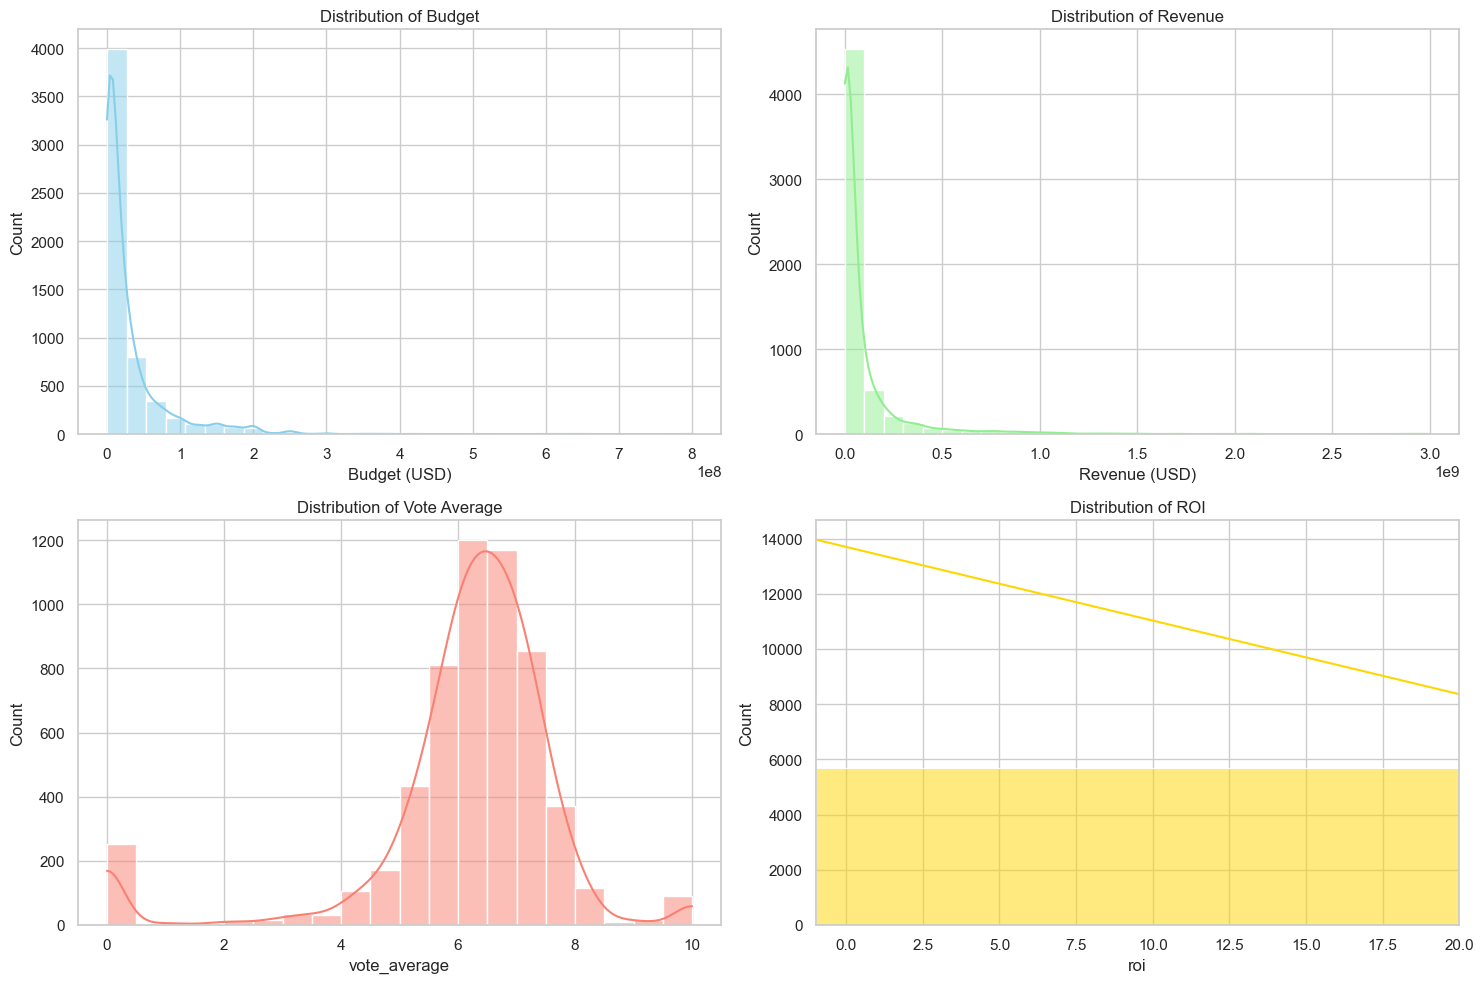

In [ ]:
# 3. Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Budget
sns.histplot(df['budget'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Budget')
axes[0,0].set_xlabel('Budget (USD)')

# Revenue
sns.histplot(df['revenue'], bins=30, kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Distribution of Revenue')
axes[0,1].set_xlabel('Revenue (USD)')

# Vote Average
sns.histplot(df['vote_average'], bins=20, kde=True, ax=axes[1,0], color='salmon')
axes[1,0].set_title('Distribution of Vote Average')

# ROI (Limit range for visibility as outliers exist)
sns.histplot(df['roi'], bins=50, kde=True, ax=axes[1,1], color='gold')
axes[1,1].set_title('Distribution of ROI')
axes[1,1].set_xlim(-1, 20) # Focusing on common range [-100% to 2000%]

plt.tight_layout()
plt.show()

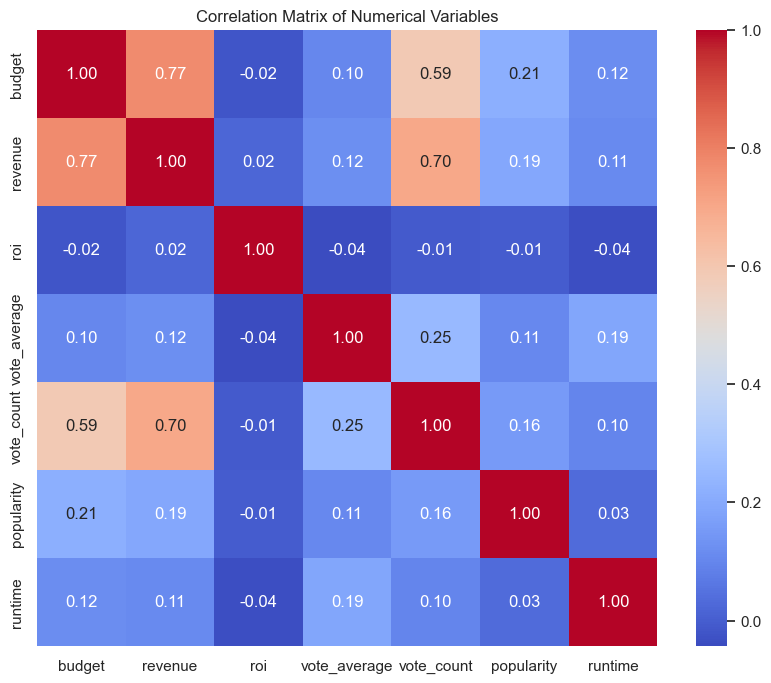

In [ ]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[['budget', 'revenue', 'roi', 'vote_average', 'vote_count', 'popularity', 'runtime']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/var/folders/yn/n87g5w9s63s668kv8lb_2hzh0000gn/T/ipykernel_88069/1483587683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


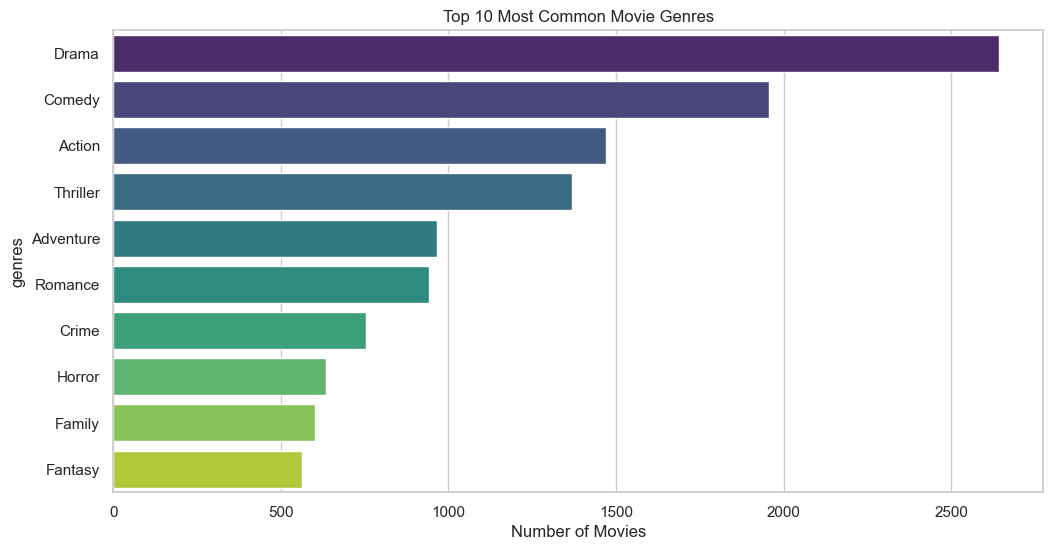

In [ ]:
# 5. Top Genres (Quick Look)
# Explode the genres column to count individual genres
genre_df = df.explode('genres')
genre_counts = genre_df['genres'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Number of Movies')
plt.show()